In [ ]:
import pandas as pd
import numpy as np

/var/folders/kl/yq_101rs6p3f1x_g6rqt6nnr0000gn/T/ipykernel_54474/2618060465.py:108: UserWarning: Glyph 128 (\x80) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/kl/yq_101rs6p3f1x_g6rqt6nnr0000gn/T/ipykernel_54474/2618060465.py:109: UserWarning: Glyph 128 (\x80) missing from font(s) DejaVu Sans.
  plt.savefig("ysl_barchart.png")
/opt/anaconda3/envs/cdj/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128 (\x80) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


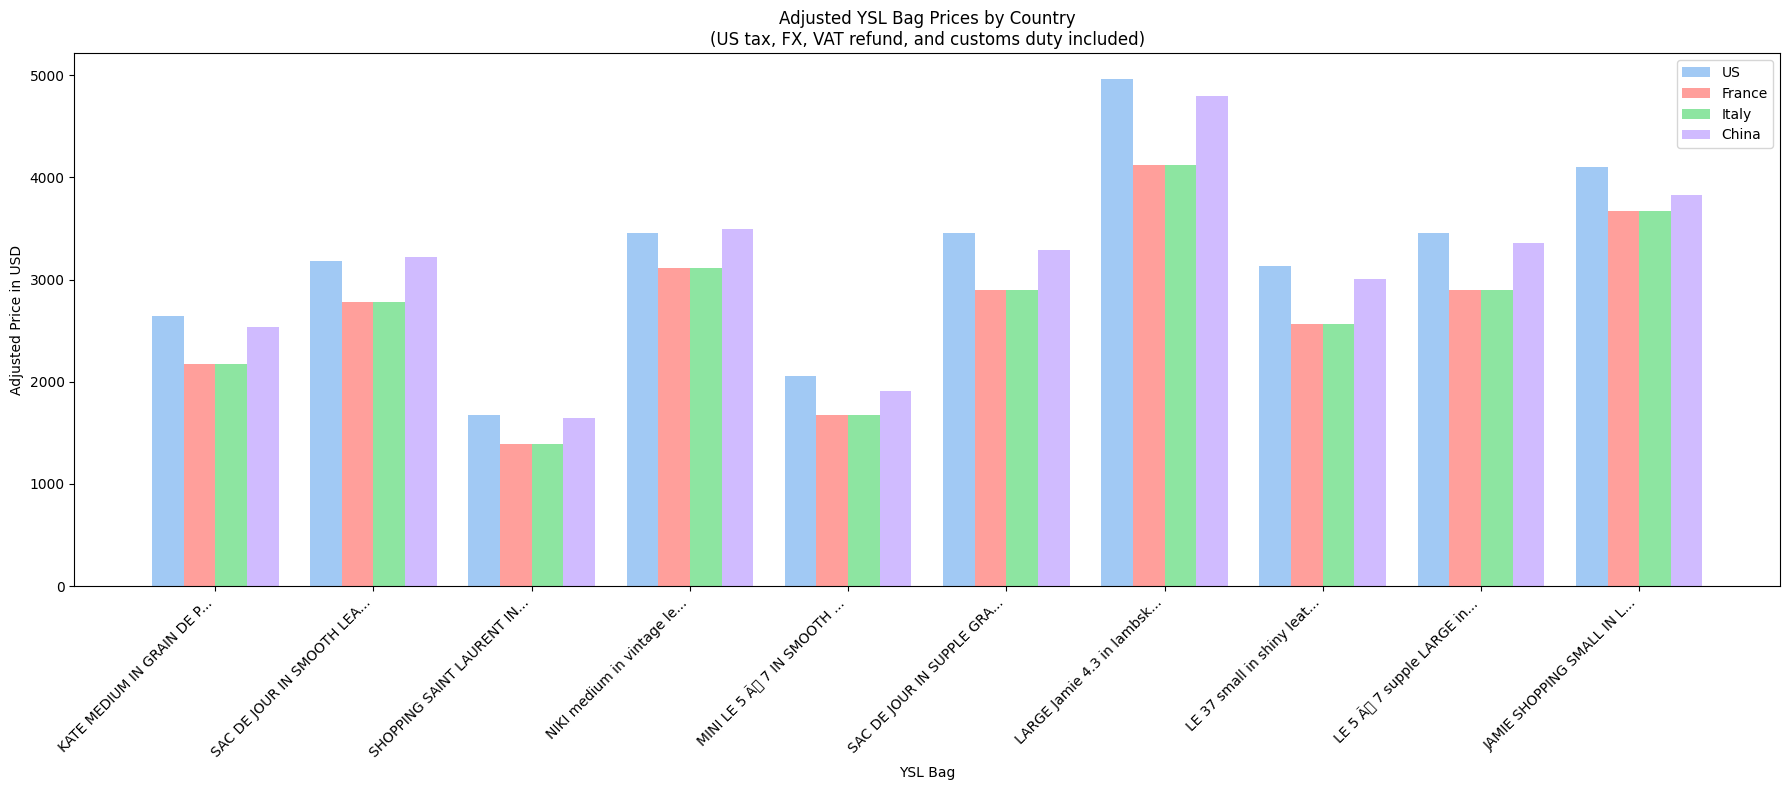

In [33]:
#LOAD DATA
vat = pd.read_csv("vat_rates_by_country.csv")
tariff = pd.read_csv("tariff_data.csv")
fx = pd.read_csv("Currency_Exchange_Rates.csv")
bags = pd.read_csv("ysl_10bags_4countries_cleaned.csv", encoding="latin1")

#STANDARDIZE DATA
vat["country"] = vat["Country"].str.strip()
vat = vat[["country", "Approx_Tax_Refund_Rate"]]

fx["country"] = fx["country"].str.strip()
fx = fx[["country", "to_us"]]

tariff["country"] = tariff["country"].str.strip()
tariff = tariff[["country", "Ad Valorem Rate"]]

# Map country codes in bags file
country_map = {
    "US": "US",
    "FR": "France",
    "IT": "Italy",
    "CN": "China"
}
bags["country_full"] = bags["country"].map(country_map)

wide = (
    bags.pivot_table(
        index=["sku", "product_name"],
        columns="country_full",
        values="price",
        aggfunc="first"
    )
    .reset_index()
)

us_sales_tax_rate = 0.08

#Build lookup dictionary
refund_lookup = dict(zip(vat["country"], vat["Approx_Tax_Refund_Rate"]))
fx_lookup = dict(zip(fx["country"], fx["to_us"]))
duty_lookup = dict(zip(tariff["country"], tariff["Ad Valorem Rate"]))

#Calculating adjusted landed costs
wide["US_total"] = wide["US"] * (1 + us_sales_tax_rate)
foreign_countries = ["France", "Italy", "China"]
for c in foreign_countries:
    # Convert local price to USD
    wide[f"{c}_converted_usd"] = wide[c] * fx_lookup[c]

    # VAT refund amount in USD
    wide[f"{c}_vat_refund_usd"] = wide[f"{c}_converted_usd"] * refund_lookup[c]

    # Net foreign price after VAT refund
    wide[f"{c}_net_after_refund"] = (
        wide[f"{c}_converted_usd"] - wide[f"{c}_vat_refund_usd"]
    )

    # Customs duty in USD
    # Assumption: duty is applied to the post-refund imported value
    wide[f"{c}_custom_duty_usd"] = (
        wide[f"{c}_net_after_refund"] * duty_lookup[c]
    )

    # Final landed cost
    wide[f"{c}_total"] = (
        wide[f"{c}_net_after_refund"] + wide[f"{c}_custom_duty_usd"]
    )

    # Savings relative to buying in the US
    wide[f"{c}_savings_vs_US"] = wide["US_total"] - wide[f"{c}_total"]


#Labels for x-axis
wide["bag_label"] = wide["product_name"].str[:25] + "..."

#grouped bar chart
plot_df = wide[["bag_label", "US_total", "France_total", "Italy_total", "China_total"]]

x = np.arange(len(plot_df))
bar_width = 0.2

plt.figure(figsize=(18, 8))

colors = {
    "US": "#a1c9f4",
    "France": "#ff9f9b",
    "Italy": "#8de5a1",
    "China": "#d0bbff"
}

plt.bar(x - 1.5 * bar_width, plot_df["US_total"], 
        width=bar_width, label="US", color=colors["US"])

plt.bar(x - 0.5 * bar_width, plot_df["France_total"], 
        width=bar_width, label="France", color=colors["France"])

plt.bar(x + 0.5 * bar_width, plot_df["Italy_total"], 
        width=bar_width, label="Italy", color=colors["Italy"])

plt.bar(x + 1.5 * bar_width, plot_df["China_total"], 
        width=bar_width, label="China", color=colors["China"])

plt.xticks(x, plot_df["bag_label"], rotation=45, ha="right")
plt.ylabel("Adjusted Price in USD")
plt.xlabel("YSL Bag")
plt.title("Adjusted YSL Bag Prices by Country\n(US tax, FX, VAT refund, and customs duty included)")
plt.legend()
plt.tight_layout()
plt.savefig("ysl_barchart.png")
plt.show()


